In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve)
import matplotlib.pyplot as plt
import joblib

In [2]:
train_df = pd.read_csv("../data/processed/train_smote.csv")
test_df = pd.read_csv("../data/processed/test_data.csv")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (1582354, 48)
Test Shape : (200000, 48)


In [3]:
X_train = train_df.drop("fraud_bool", axis=1)
y_train = train_df["fraud_bool"]
X_test = test_df.drop("fraud_bool", axis=1)
y_test = test_df["fraud_bool"]

In [4]:
xgb = XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=6,objective="binary:logistic",
    eval_metric="logloss",random_state=42)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [6]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.98533
Precision: 0.20212765957446807
Recall   : 0.11196736174070716
F1 Score : 0.1441073512252042
ROC AUC  : 0.8539954182850806


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    197794
           1       0.20      0.11      0.14      2206

    accuracy                           0.99    200000
   macro avg       0.60      0.55      0.57    200000
weighted avg       0.98      0.99      0.98    200000



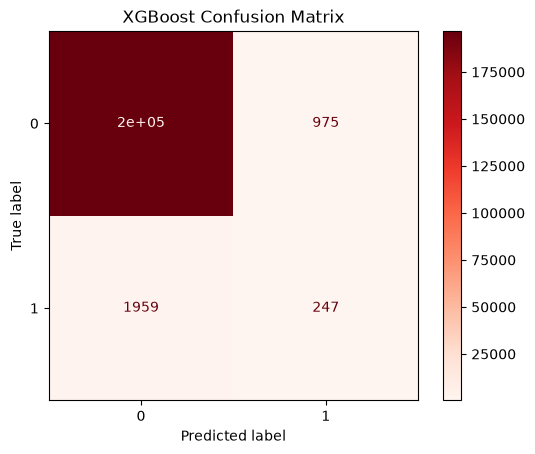

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("XGBoost Confusion Matrix")
plt.show()

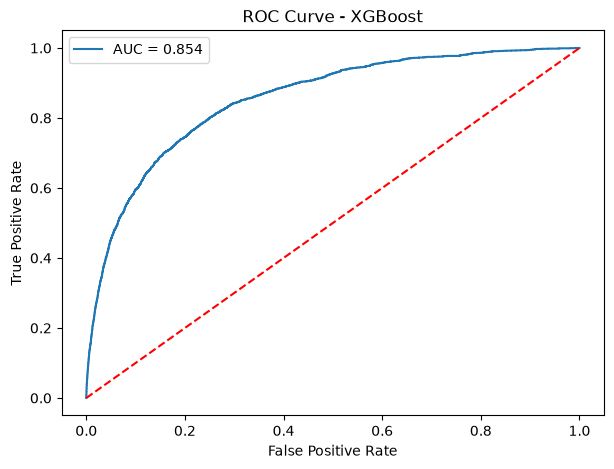

In [10]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [11]:
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": xgb.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(20)

,Feature,Importance
22,keep_alive_session,0.149359
18,has_other_cards,0.132721
39,housing_status_4,0.107136
44,device_os_2,0.089188
38,housing_status_3,0.074979
15,phone_home_valid,0.056748
36,housing_status_1,0.047569
37,housing_status_2,0.045072
30,employment_status_1,0.040477
4,customer_age,0.035334


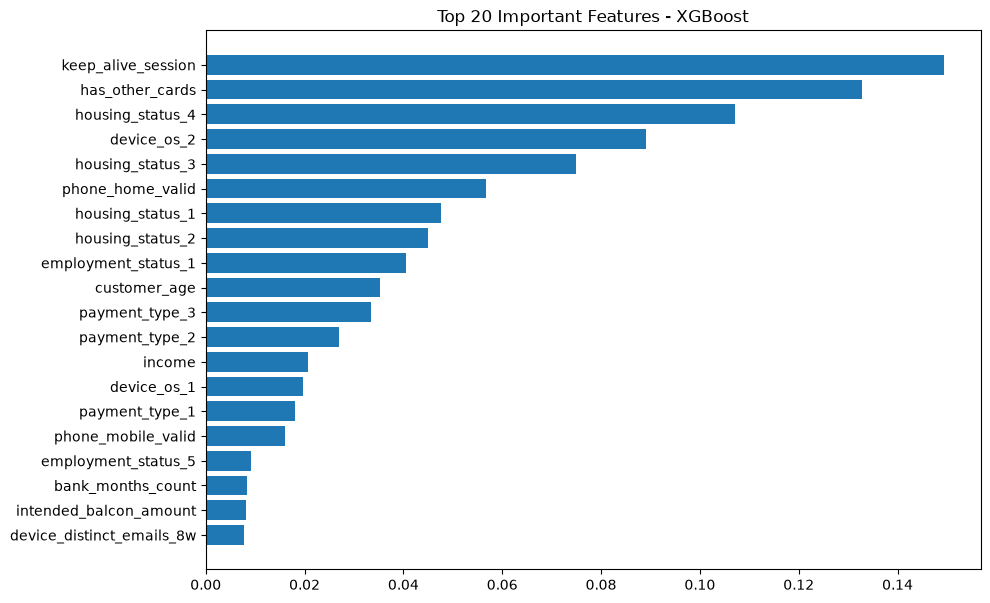

In [12]:
top20 = importance.head(20)
plt.figure(figsize=(10,7))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - XGBoost")
plt.show()

In [13]:
importance.to_csv("../data/processed/xgboost_feature_importance.csv",index=False)
print("Feature importance saved successfully.")

Feature importance saved successfully.


In [14]:
joblib.dump(xgb,"../models/xgboost.pkl")
print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## Summary

- Loaded the SMOTE-balanced training dataset and original test dataset.
- Trained an XGBoost classifier for binary fraud detection.
- Evaluated model performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Generated a Classification Report and Confusion Matrix.
- Plotted the ROC Curve to assess classification performance.
- Calculated and visualized the top 20 most important features.
- Saved feature importance to the processed data folder.
- Saved the trained XGBoost model for future prediction and deployment.